# Confronto Flower Bagging vs Cyclic
## NECSTLab - Polimi LS2

Analisi comparativa dei due approcci di Federated Learning con XGBoost

In [ ]:
import pandas as pd # per gestire i DataFrame
import numpy as np # per gestire array e operazioni numeriche
import matplotlib.pyplot as plt # per visualizzare i grafici
import seaborn as sns # per migliorare l'estetica dei grafici
import xgboost as xgb # per il modello XGBoost
from pathlib import Path # per gestire i percorsi dei file
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # per valutare le performance dei modelli
import warnings # per gestire i messaggi di avviso
warnings.filterwarnings('ignore')

# Setup plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Import completati")

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


✅ Import completati


## 1. Caricamento Modelli

In [ ]:
# Percorsi modelli
bagging_path = Path('../benchmarks/flower_bagging/results/final_model.json')
cyclic_path = Path('../benchmarks/flower_cyclic/results/final_model.json')

# Carica modelli
bst_bagging = xgb.Booster() #XGBoost Booster: È l'oggetto principale di XGBoost che contiene gli alberi del modello addestrato.
bst_bagging.load_model(str(bagging_path))

bst_cyclic = xgb.Booster()
bst_cyclic.load_model(str(cyclic_path))

print(f"✅ Modelli caricati:")
print(f"   Bagging: {bagging_path.name} ({bagging_path.stat().st_size / 1024:.1f} KB)")
print(f"   Cyclic:  {cyclic_path.name} ({cyclic_path.stat().st_size / 1024:.1f} KB)")

✅ Modelli caricati:
   Bagging: final_model.json (220.3 KB)
   Cyclic:  final_model.json (106.2 KB)


## 2. Confronto Struttura Modelli

,Metrica,Bagging,Cyclic,Differenza (%)
0,Numero Alberi,94.000000,50.00000,-46.81
1,Dimensione File (KB),220.307617,106.15332,-51.82
2,Features Utilizzate,38.000000,37.00000,-2.63


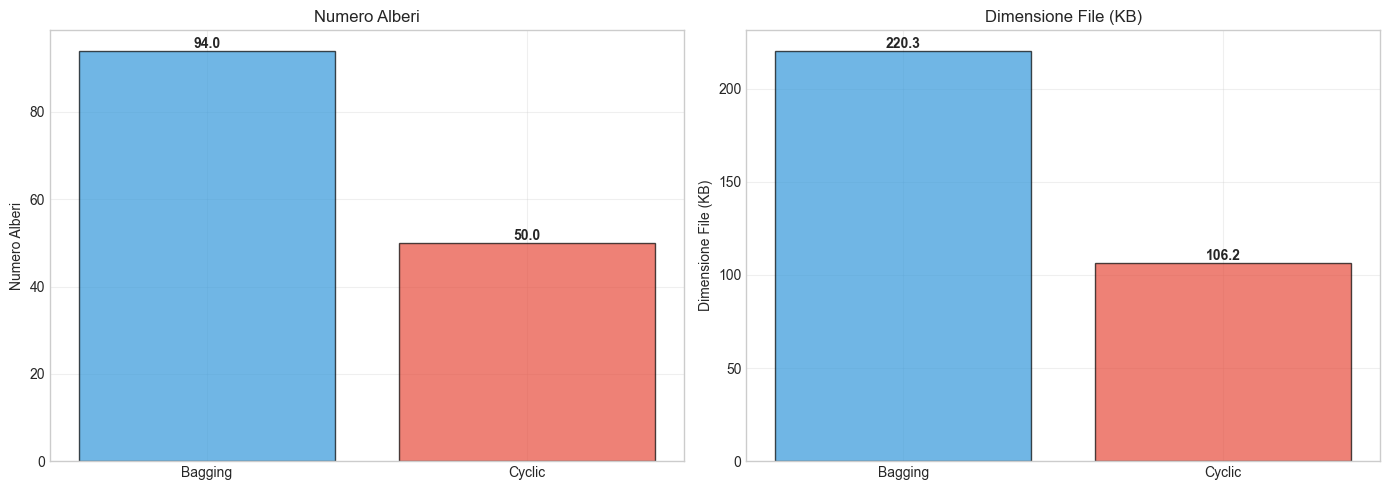


💡 Osservazioni:
   - Cyclic usa -46.8% alberi rispetto a Bagging
   - Cyclic è 51.8% più leggero


In [ ]:
# Statistiche strutturali
data = {
    'Metrica': ['Numero Alberi', 'Dimensione File (KB)', 'Features Utilizzate'],
    'Bagging': [
        bst_bagging.num_boosted_rounds(), # conta il numero di alberi nel modello
        bagging_path.stat().st_size / 1024, # converte la dimensione del file in KB
        len(bst_bagging.get_score(importance_type='gain')) # conta il numero di feature utilizzate (importanza basata su 'gain')
    ],
    'Cyclic': [
        bst_cyclic.num_boosted_rounds(),
        cyclic_path.stat().st_size / 1024,
        len(bst_cyclic.get_score(importance_type='gain'))
    ]
}

df_structure = pd.DataFrame(data)
df_structure['Differenza (%)'] = ((df_structure['Cyclic'] - df_structure['Bagging']) / df_structure['Bagging'] * 100).round(2)

display(df_structure)

# Visualizzazione
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Numero alberi
metrics = ['Numero Alberi', 'Dimensione File (KB)']
for i, metric in enumerate(metrics):
    row = df_structure[df_structure['Metrica'] == metric].iloc[0]
    axes[i].bar(['Bagging', 'Cyclic'], [row['Bagging'], row['Cyclic']], 
                color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'{metric}')
    axes[i].grid(True, alpha=0.3)
    
    # Aggiungi valori sopra le barre
    for j, (label, val) in enumerate([('Bagging', row['Bagging']), ('Cyclic', row['Cyclic'])]):
        axes[i].text(j, val, f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Osservazioni:")
print(f"   - Cyclic usa {df_structure.loc[0, 'Differenza (%)']:.1f}% alberi rispetto a Bagging")
print(f"   - Cyclic è {100 - (df_structure.loc[1, 'Cyclic'] / df_structure.loc[1, 'Bagging'] * 100):.1f}% più leggero")

## 3. Feature Importance Comparison

Confrontiamo quali feature sono considerate più importanti dai due approcci

📊 Top 15 Feature più Importanti (media tra i due approcci):


,Feature,Bagging,Cyclic,Media
2,resp_avgTomorrowSleepRespirationValue,1308.738037,1554.623169,1431.680603
11,act_totalCalories,816.548340,1073.003662,944.776001
36,sleep_napTimeSeconds,443.692322,1324.529663,884.110992
32,hr_mean,509.001038,1007.244080,758.122559
15,stress_std,1000.314331,505.454742,752.884537
8,sleep_unmeasurableSleepSeconds,1361.065918,0.000000,680.532959
38,stress_mean,474.302460,745.523254,609.912857
9,sleep_highestRespirationValue,479.402191,679.871826,579.637009
6,sleep_averageRespirationValue,1135.555542,0.000000,567.777771
33,resp_avgWakingRespirationValue,447.990753,636.355713,542.173233


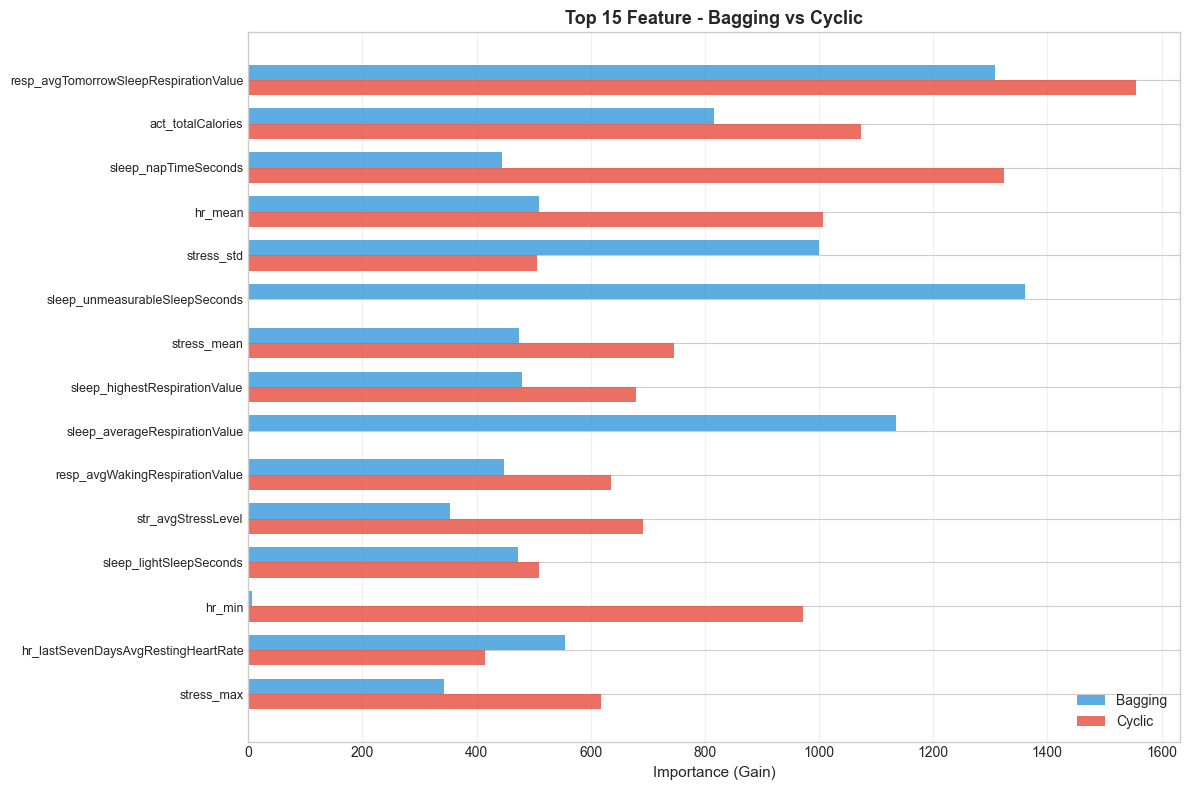

In [4]:
# Estrai feature importance
importance_bagging = bst_bagging.get_score(importance_type='gain')
importance_cyclic = bst_cyclic.get_score(importance_type='gain')

# Crea DataFrame comparativo
df_importance = pd.DataFrame({
    'Feature': list(set(list(importance_bagging.keys()) + list(importance_cyclic.keys()))),
})

df_importance['Bagging'] = df_importance['Feature'].map(importance_bagging).fillna(0)
df_importance['Cyclic'] = df_importance['Feature'].map(importance_cyclic).fillna(0)
df_importance['Media'] = (df_importance['Bagging'] + df_importance['Cyclic']) / 2
df_importance = df_importance.sort_values('Media', ascending=False)

# Top 15
top_features = df_importance.head(15)

print("📊 Top 15 Feature più Importanti (media tra i due approcci):")
display(top_features)

# Visualizzazione comparativa
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(top_features))
width = 0.35

bars1 = ax.barh(x - width/2, top_features['Bagging'], width, label='Bagging', alpha=0.8, color='#3498db')
bars2 = ax.barh(x + width/2, top_features['Cyclic'], width, label='Cyclic', alpha=0.8, color='#e74c3c')

ax.set_yticks(x)
ax.set_yticklabels(top_features['Feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)', fontsize=11)
ax.set_title('Top 15 Feature - Bagging vs Cyclic', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. Performance su Test Set

Valutiamo le performance dei due modelli su dati di test

📈 Performance su Test Set (107 campioni):



,Metrica,Bagging,Cyclic,Differenza,Migliore
0,MAE,12.228979,11.381941,-0.847038,Cyclic
1,RMSE,15.564315,14.827487,-0.736828,Cyclic
2,R²,-0.161625,-0.054244,0.107381,Cyclic


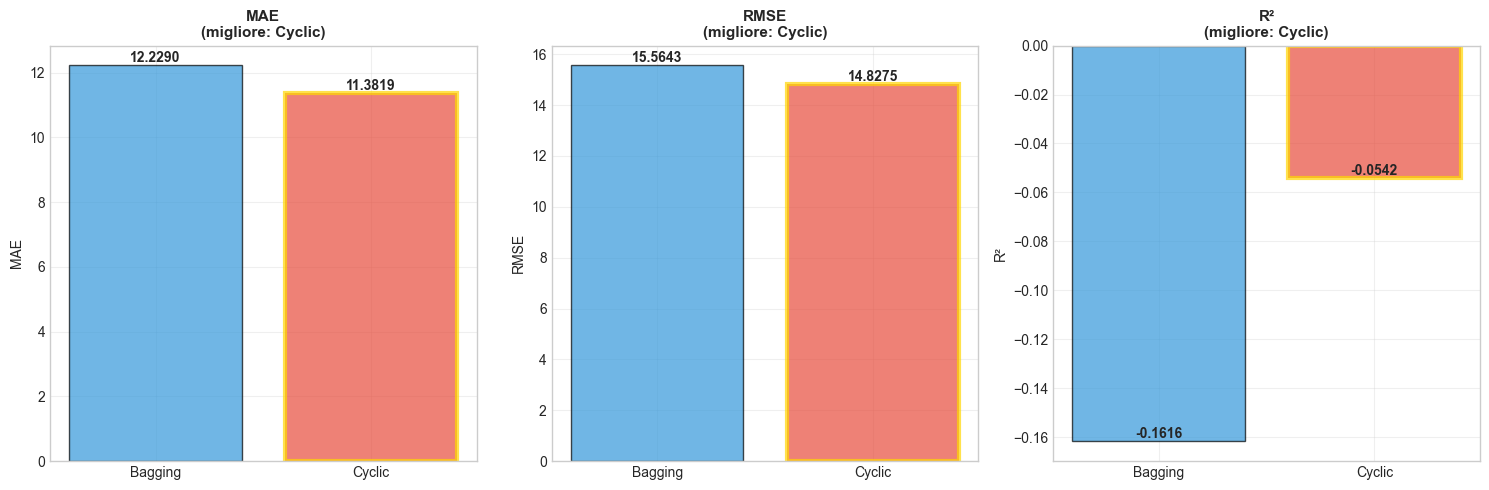

In [6]:
# Carica dati di test (usando client_0 come test set)
test_path = Path('../data/ready_for_flwr/client_0.csv')

if test_path.exists():
    df_test = pd.read_csv(test_path)
    
    # Prepara dati
    X_test = df_test.drop(['day', 'label'], axis=1, errors='ignore')
    y_test = df_test['label']
    
    # Aggiungi colonna mancante se necessario
    if 'act_activeTime' not in X_test.columns:
        X_test['act_activeTime'] = 0
    
    # Ordina colonne come il modello bagging si aspetta
    model_features = bst_bagging.feature_names
    X_test = X_test[[f for f in model_features if f in X_test.columns]]
    
    # Crea DMatrix
    dtest = xgb.DMatrix(X_test, label=y_test)
    
    # Predizioni
    y_pred_bagging = bst_bagging.predict(dtest)
    y_pred_cyclic = bst_cyclic.predict(dtest)
    
    # Calcola metriche
    metrics_data = {
        'Metrica': ['MAE', 'RMSE', 'R²'],
        'Bagging': [
            mean_absolute_error(y_test, y_pred_bagging),
            np.sqrt(mean_squared_error(y_test, y_pred_bagging)),
            r2_score(y_test, y_pred_bagging)
        ],
        'Cyclic': [
            mean_absolute_error(y_test, y_pred_cyclic),
            np.sqrt(mean_squared_error(y_test, y_pred_cyclic)),
            r2_score(y_test, y_pred_cyclic)
        ]
    }
    
    df_metrics = pd.DataFrame(metrics_data)
    df_metrics['Differenza'] = df_metrics['Cyclic'] - df_metrics['Bagging']
    df_metrics['Migliore'] = df_metrics.apply(
        lambda row: 'Bagging' if (row['Metrica'] == 'R²' and row['Bagging'] > row['Cyclic']) or 
                                   (row['Metrica'] != 'R²' and row['Bagging'] < row['Cyclic']) 
                    else 'Cyclic', 
        axis=1
    )
    
    print(f"📈 Performance su Test Set ({len(y_test)} campioni):\n")
    display(df_metrics)
    
    # Visualizzazione metriche
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
        row = df_metrics[df_metrics['Metrica'] == metric].iloc[0]
        
        bars = axes[i].bar(['Bagging', 'Cyclic'], [row['Bagging'], row['Cyclic']], 
                          color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
        
        # Evidenzia il migliore
        winner_idx = 0 if row['Migliore'] == 'Bagging' else 1
        bars[winner_idx].set_edgecolor('gold')
        bars[winner_idx].set_linewidth(3)
        
        axes[i].set_ylabel(metric)
        axes[i].set_title(f'{metric}\n(migliore: {row["Migliore"]})', fontsize=11, fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        
        # Valori sopra barre
        for j, (label, val) in enumerate([('Bagging', row['Bagging']), ('Cyclic', row['Cyclic'])]):
            axes[i].text(j, val, f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"⚠️ File non trovato: {test_path}")

## 5. Distribuzione Predizioni vs Valori Reali

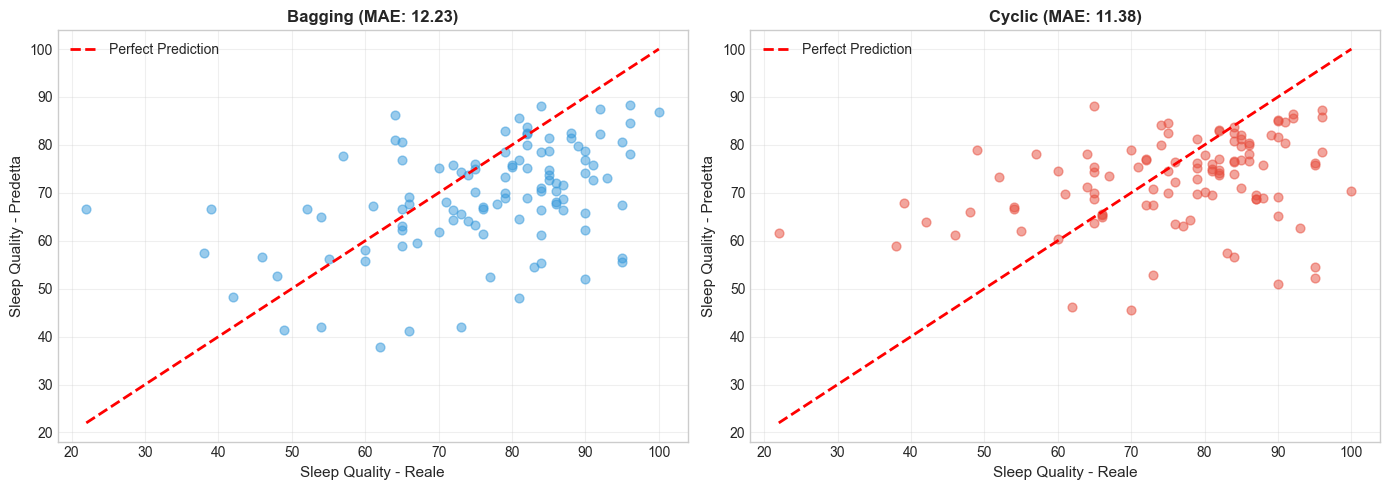

In [7]:
if 'y_pred_bagging' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bagging
    axes[0].scatter(y_test, y_pred_bagging, alpha=0.5, s=40, color='#3498db')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Sleep Quality - Reale', fontsize=11)
    axes[0].set_ylabel('Sleep Quality - Predetta', fontsize=11)
    axes[0].set_title(f'Bagging (MAE: {mean_absolute_error(y_test, y_pred_bagging):.2f})', 
                     fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Cyclic
    axes[1].scatter(y_test, y_pred_cyclic, alpha=0.5, s=40, color='#e74c3c')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                 'r--', lw=2, label='Perfect Prediction')
    axes[1].set_xlabel('Sleep Quality - Reale', fontsize=11)
    axes[1].set_ylabel('Sleep Quality - Predetta', fontsize=11)
    axes[1].set_title(f'Cyclic (MAE: {mean_absolute_error(y_test, y_pred_cyclic):.2f})', 
                     fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Distribuzione Errori

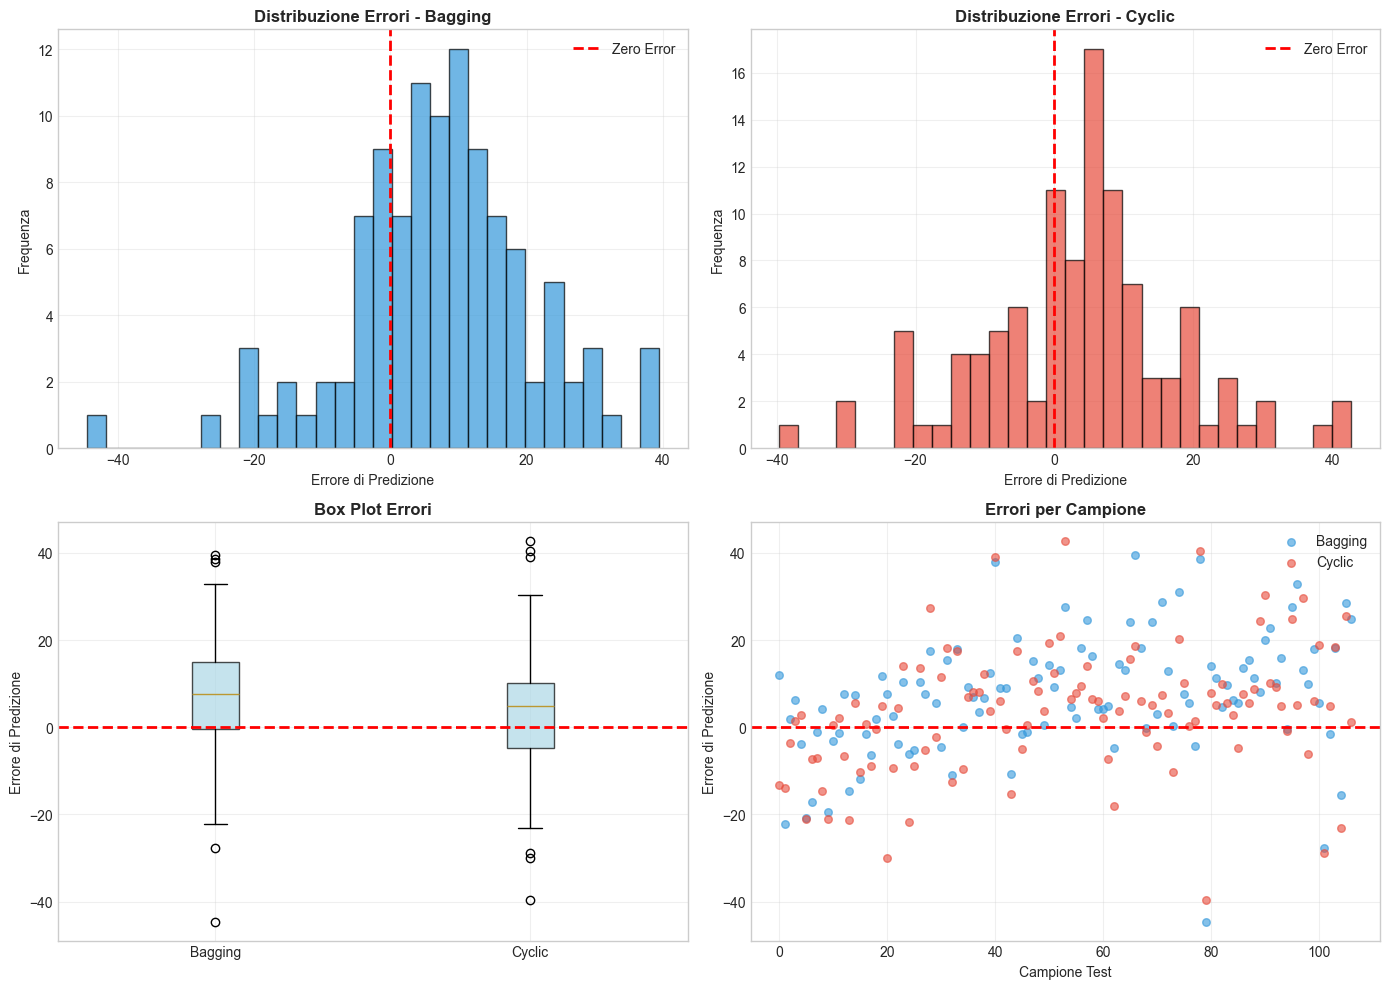

📊 Statistiche Errori:



,Statistica,Bagging,Cyclic
0,Media,7.248153,3.648243
1,Std Dev,13.838422,14.439295
2,Min,-44.562225,-39.630051
3,Max,39.412605,42.746769
4,Mediana,7.564175,4.969727


In [8]:
if 'y_pred_bagging' in locals():
    errors_bagging = y_test - y_pred_bagging
    errors_cyclic = y_test - y_pred_cyclic
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Istogrammi errori
    axes[0, 0].hist(errors_bagging, bins=30, alpha=0.7, color='#3498db', edgecolor='black')
    axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[0, 0].set_xlabel('Errore di Predizione')
    axes[0, 0].set_ylabel('Frequenza')
    axes[0, 0].set_title('Distribuzione Errori - Bagging', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].hist(errors_cyclic, bins=30, alpha=0.7, color='#e74c3c', edgecolor='black')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[0, 1].set_xlabel('Errore di Predizione')
    axes[0, 1].set_ylabel('Frequenza')
    axes[0, 1].set_title('Distribuzione Errori - Cyclic', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Box plots
    axes[1, 0].boxplot([errors_bagging, errors_cyclic], labels=['Bagging', 'Cyclic'],
                       patch_artist=True, 
                       boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_ylabel('Errore di Predizione')
    axes[1, 0].set_title('Box Plot Errori', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Scatter plot errori
    axes[1, 1].scatter(range(len(errors_bagging)), errors_bagging, alpha=0.6, s=30, 
                      color='#3498db', label='Bagging')
    axes[1, 1].scatter(range(len(errors_cyclic)), errors_cyclic, alpha=0.6, s=30, 
                      color='#e74c3c', label='Cyclic')
    axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('Campione Test')
    axes[1, 1].set_ylabel('Errore di Predizione')
    axes[1, 1].set_title('Errori per Campione', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiche errori
    print("📊 Statistiche Errori:\n")
    stats_data = {
        'Statistica': ['Media', 'Std Dev', 'Min', 'Max', 'Mediana'],
        'Bagging': [
            errors_bagging.mean(),
            errors_bagging.std(),
            errors_bagging.min(),
            errors_bagging.max(),
            errors_bagging.median()
        ],
        'Cyclic': [
            errors_cyclic.mean(),
            errors_cyclic.std(),
            errors_cyclic.min(),
            errors_cyclic.max(),
            errors_cyclic.median()
        ]
    }
    
    df_stats = pd.DataFrame(stats_data)
    display(df_stats)

## 7. Analisi Tempi di Esecuzione

Confrontiamo i tempi di training, comunicazione e overhead dei due approcci

⏱️  Confronto Tempi di Esecuzione:



,Metrica,Bagging,Cyclic,Differenza (%)
0,Tempo Totale (s),26.316734,19.621081,-25.44
1,Tempo FL (s),26.258841,19.588958,-25.40
2,Tempo/Round (s),2.625884,1.958896,-25.40
3,Numero Rounds,10.000000,10.000000,0.00


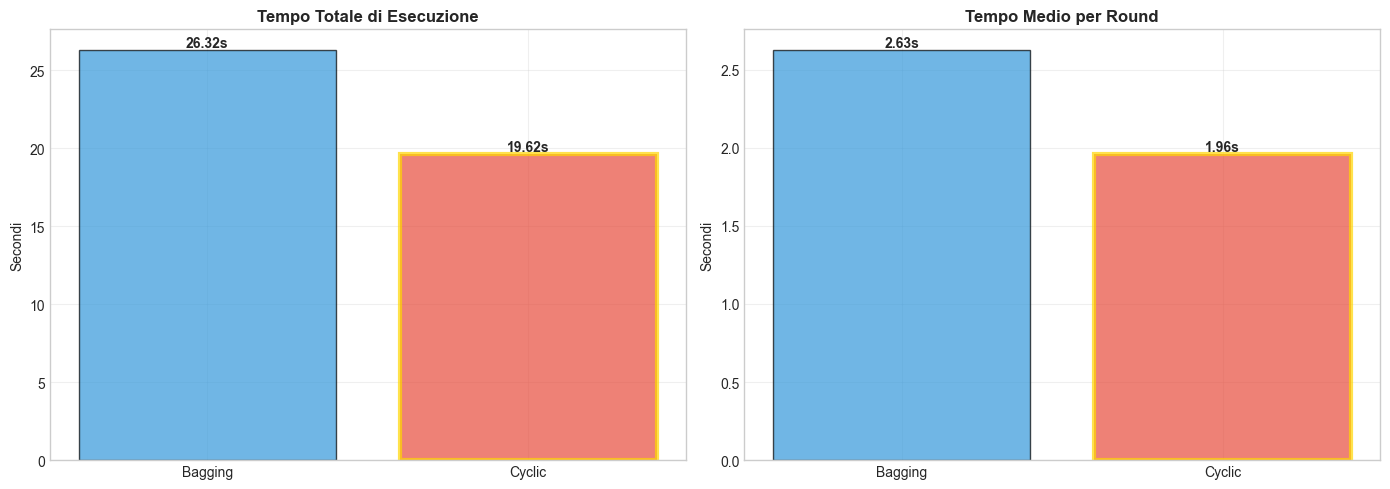


💡 Osservazioni:
   - Cyclic è 25.4% più veloce di Bagging
   - Risparmio temporale: 6.70s
   - Cyclic completa un round in media in 1.96s vs 2.63s di Bagging


In [10]:
import json

# Carica metriche temporali
timing_bagging_path = Path('../benchmarks/flower_bagging/results/timing_metrics.json')
timing_cyclic_path = Path('../benchmarks/flower_cyclic/results/timing_metrics.json')

if timing_bagging_path.exists() and timing_cyclic_path.exists():
    with open(timing_bagging_path, 'r') as f:
        timing_bagging = json.load(f)
    
    with open(timing_cyclic_path, 'r') as f:
        timing_cyclic = json.load(f)
    
    # Crea DataFrame comparativo
    timing_data = {
        'Metrica': ['Tempo Totale (s)', 'Tempo FL (s)', 'Tempo/Round (s)', 'Numero Rounds'],
        'Bagging': [
            timing_bagging['total_time'],
            timing_bagging['fl_time'],
            timing_bagging['avg_round_time'],
            timing_bagging['num_rounds']
        ],
        'Cyclic': [
            timing_cyclic['total_time'],
            timing_cyclic['fl_time'],
            timing_cyclic['avg_round_time'],
            timing_cyclic['num_rounds']
        ]
    }
    
    df_timing = pd.DataFrame(timing_data)
    df_timing['Differenza (%)'] = ((df_timing['Cyclic'] - df_timing['Bagging']) / df_timing['Bagging'] * 100).round(2)
    
    print("⏱️  Confronto Tempi di Esecuzione:\n")
    display(df_timing)
    
    # Visualizzazione
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Tempo totale
    total_times = [timing_bagging['total_time'], timing_cyclic['total_time']]
    bars = axes[0].bar(['Bagging', 'Cyclic'], total_times, 
                       color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
    axes[0].set_ylabel('Secondi')
    axes[0].set_title('Tempo Totale di Esecuzione', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Evidenzia il più veloce
    faster_idx = 0 if timing_bagging['total_time'] < timing_cyclic['total_time'] else 1
    bars[faster_idx].set_edgecolor('gold')
    bars[faster_idx].set_linewidth(3)
    
    for i, val in enumerate(total_times):
        axes[0].text(i, val, f'{val:.2f}s', ha='center', va='bottom', fontweight='bold')
    
    # Tempo per round
    round_times = [timing_bagging['avg_round_time'], timing_cyclic['avg_round_time']]
    bars2 = axes[1].bar(['Bagging', 'Cyclic'], round_times,
                        color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
    axes[1].set_ylabel('Secondi')
    axes[1].set_title('Tempo Medio per Round', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Evidenzia il più veloce
    bars2[faster_idx].set_edgecolor('gold')
    bars2[faster_idx].set_linewidth(3)
    
    for i, val in enumerate(round_times):
        axes[1].text(i, val, f'{val:.2f}s', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Statistiche riassuntive
    speedup = (timing_bagging['total_time'] - timing_cyclic['total_time']) / timing_bagging['total_time'] * 100
    print(f"\n💡 Osservazioni:")
    print(f"   - Cyclic è {abs(speedup):.1f}% {'più veloce' if speedup > 0 else 'più lento'} di Bagging")
    print(f"   - Risparmio temporale: {abs(timing_bagging['total_time'] - timing_cyclic['total_time']):.2f}s")
    print(f"   - Cyclic completa un round in media in {timing_cyclic['avg_round_time']:.2f}s vs {timing_bagging['avg_round_time']:.2f}s di Bagging")
    
else:
    print("⚠️ File timing_metrics.json non trovati")

## 8. Efficienza Computazionale

Confronto tra efficienza temporale e qualità del modello

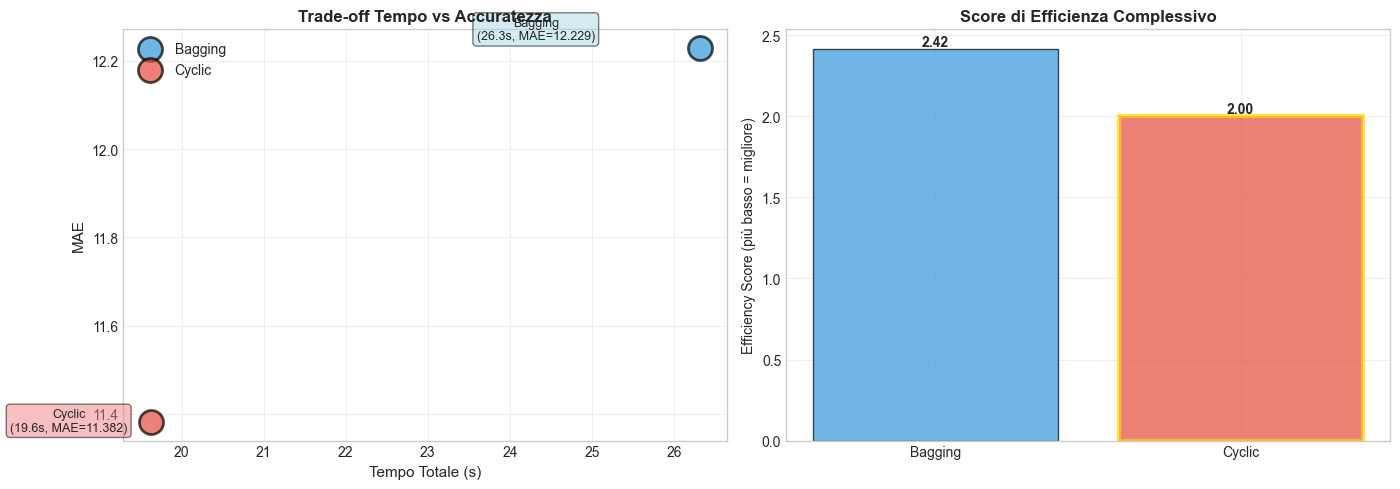


📊 Analisi Efficienza:
   Bagging: MAE=12.2290, Tempo=26.32s, Score=2.42
   Cyclic:  MAE=11.3819, Tempo=19.62s, Score=2.00

   🏅 Più efficiente: Cyclic


In [11]:
if 'df_metrics' in locals() and 'df_timing' in locals():
    # Crea metrica combinata: accuratezza / tempo
    mae_bagging = df_metrics[df_metrics['Metrica'] == 'MAE']['Bagging'].iloc[0]
    mae_cyclic = df_metrics[df_metrics['Metrica'] == 'MAE']['Cyclic'].iloc[0]
    
    time_bagging = timing_bagging['total_time']
    time_cyclic = timing_cyclic['total_time']
    
    # Efficiency score: minore MAE e minore tempo = migliore
    # Normalizziamo entrambe le metriche
    mae_norm_bagging = mae_bagging / min(mae_bagging, mae_cyclic)
    mae_norm_cyclic = mae_cyclic / min(mae_bagging, mae_cyclic)
    
    time_norm_bagging = time_bagging / min(time_bagging, time_cyclic)
    time_norm_cyclic = time_cyclic / min(time_bagging, time_cyclic)
    
    # Score combinato (più basso = migliore)
    efficiency_bagging = mae_norm_bagging + time_norm_bagging
    efficiency_cyclic = mae_norm_cyclic + time_norm_cyclic
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot: Tempo vs MAE
    axes[0].scatter([time_bagging], [mae_bagging], s=300, alpha=0.7, 
                   color='#3498db', edgecolor='black', linewidth=2, label='Bagging')
    axes[0].scatter([time_cyclic], [mae_cyclic], s=300, alpha=0.7, 
                   color='#e74c3c', edgecolor='black', linewidth=2, label='Cyclic')
    
    axes[0].set_xlabel('Tempo Totale (s)', fontsize=11)
    axes[0].set_ylabel('MAE', fontsize=11)
    axes[0].set_title('Trade-off Tempo vs Accuratezza', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Annotazioni
    axes[0].annotate(f'Bagging\n({time_bagging:.1f}s, MAE={mae_bagging:.3f})',
                    xy=(time_bagging, mae_bagging), xytext=(time_bagging-2, mae_bagging+0.02),
                    fontsize=9, ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))
    
    axes[0].annotate(f'Cyclic\n({time_cyclic:.1f}s, MAE={mae_cyclic:.3f})',
                    xy=(time_cyclic, mae_cyclic), xytext=(time_cyclic-1, mae_cyclic-0.02),
                    fontsize=9, ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.5))
    
    # Efficiency score
    efficiency_scores = [efficiency_bagging, efficiency_cyclic]
    bars = axes[1].bar(['Bagging', 'Cyclic'], efficiency_scores,
                      color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
    axes[1].set_ylabel('Efficiency Score (più basso = migliore)')
    axes[1].set_title('Score di Efficienza Complessivo', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Evidenzia il migliore
    best_idx = 0 if efficiency_bagging < efficiency_cyclic else 1
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    
    for i, val in enumerate(efficiency_scores):
        axes[1].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Analisi Efficienza:")
    print(f"   Bagging: MAE={mae_bagging:.4f}, Tempo={time_bagging:.2f}s, Score={efficiency_bagging:.2f}")
    print(f"   Cyclic:  MAE={mae_cyclic:.4f}, Tempo={time_cyclic:.2f}s, Score={efficiency_cyclic:.2f}")
    print(f"\n   🏅 Più efficiente: {'Bagging' if efficiency_bagging < efficiency_cyclic else 'Cyclic'}")

## 9. Confronto Complessivo: Tempi vs Accuratezza

Analisi integrata di tutte le metriche per determinare l'approccio ottimale

In [12]:
# Tabella riassuntiva completa
if 'df_metrics' in locals() and 'df_timing' in locals():
    
    # Raccogli tutte le metriche chiave
    mae_bagging = df_metrics[df_metrics['Metrica'] == 'MAE']['Bagging'].iloc[0]
    mae_cyclic = df_metrics[df_metrics['Metrica'] == 'MAE']['Cyclic'].iloc[0]
    
    rmse_bagging = df_metrics[df_metrics['Metrica'] == 'RMSE']['Bagging'].iloc[0]
    rmse_cyclic = df_metrics[df_metrics['Metrica'] == 'RMSE']['Cyclic'].iloc[0]
    
    r2_bagging = df_metrics[df_metrics['Metrica'] == 'R²']['Bagging'].iloc[0]
    r2_cyclic = df_metrics[df_metrics['Metrica'] == 'R²']['Cyclic'].iloc[0]
    
    # Tabella riassuntiva
    summary_data = {
        'Categoria': ['Accuratezza', 'Accuratezza', 'Accuratezza', 
                      'Struttura', 'Struttura', 
                      'Performance', 'Performance', 'Performance'],
        'Metrica': ['MAE ↓', 'RMSE ↓', 'R² ↑', 
                   'Numero Alberi', 'Dimensione (KB)',
                   'Tempo Totale (s) ↓', 'Tempo/Round (s) ↓', 'Efficiency Score ↓'],
        'Bagging': [
            mae_bagging,
            rmse_bagging,
            r2_bagging,
            bst_bagging.num_boosted_rounds(),
            bagging_path.stat().st_size / 1024,
            timing_bagging['total_time'],
            timing_bagging['avg_round_time'],
            efficiency_bagging
        ],
        'Cyclic': [
            mae_cyclic,
            rmse_cyclic,
            r2_cyclic,
            bst_cyclic.num_boosted_rounds(),
            cyclic_path.stat().st_size / 1024,
            timing_cyclic['total_time'],
            timing_cyclic['avg_round_time'],
            efficiency_cyclic
        ]
    }
    
    df_summary = pd.DataFrame(summary_data)
    
    # Determina il vincitore per ogni metrica
    def determine_winner(row):
        metric = row['Metrica']
        bagging_val = row['Bagging']
        cyclic_val = row['Cyclic']
        
        # Per metriche da minimizzare (↓)
        if '↓' in metric:
            return '🏆 Cyclic' if cyclic_val < bagging_val else '🏆 Bagging'
        # Per metriche da massimizzare (↑)
        elif '↑' in metric:
            return '🏆 Cyclic' if cyclic_val > bagging_val else '🏆 Bagging'
        # Altri casi (numeri puri)
        else:
            return '-'
    
    df_summary['Vincitore'] = df_summary.apply(determine_winner, axis=1)
    
    # Calcola differenza percentuale
    df_summary['Diff %'] = ((df_summary['Cyclic'] - df_summary['Bagging']) / df_summary['Bagging'] * 100).round(2)
    
    print("=" * 90)
    print("📊 TABELLA RIASSUNTIVA COMPLETA - BAGGING vs CYCLIC")
    print("=" * 90)
    print()
    display(df_summary)
    
    # Conta i vincitori
    cyclic_wins = (df_summary['Vincitore'] == '🏆 Cyclic').sum()
    bagging_wins = (df_summary['Vincitore'] == '🏆 Bagging').sum()
    
    print(f"\n🏅 PUNTEGGIO COMPLESSIVO:")
    print(f"   Cyclic:  {cyclic_wins} metriche vinte")
    print(f"   Bagging: {bagging_wins} metriche vinte")

📊 TABELLA RIASSUNTIVA COMPLETA - BAGGING vs CYCLIC



,Categoria,Metrica,Bagging,Cyclic,Vincitore,Diff %
0,Accuratezza,MAE ↓,12.228979,11.381941,🏆 Cyclic,-6.93
1,Accuratezza,RMSE ↓,15.564315,14.827487,🏆 Cyclic,-4.73
2,Accuratezza,R² ↑,-0.161625,-0.054244,🏆 Cyclic,-66.44
3,Struttura,Numero Alberi,94.000000,50.000000,-,-46.81
4,Struttura,Dimensione (KB),217.378906,111.284180,-,-48.81
5,Performance,Tempo Totale (s) ↓,26.316734,19.621081,🏆 Cyclic,-25.44
6,Performance,Tempo/Round (s) ↓,2.625884,1.958896,🏆 Cyclic,-25.40
7,Performance,Efficiency Score ↓,2.415667,2.000000,🏆 Cyclic,-17.21



🏅 PUNTEGGIO COMPLESSIVO:
   Cyclic:  6 metriche vinte
   Bagging: 0 metriche vinte


### Visualizzazione Radar - Confronto Multi-dimensionale

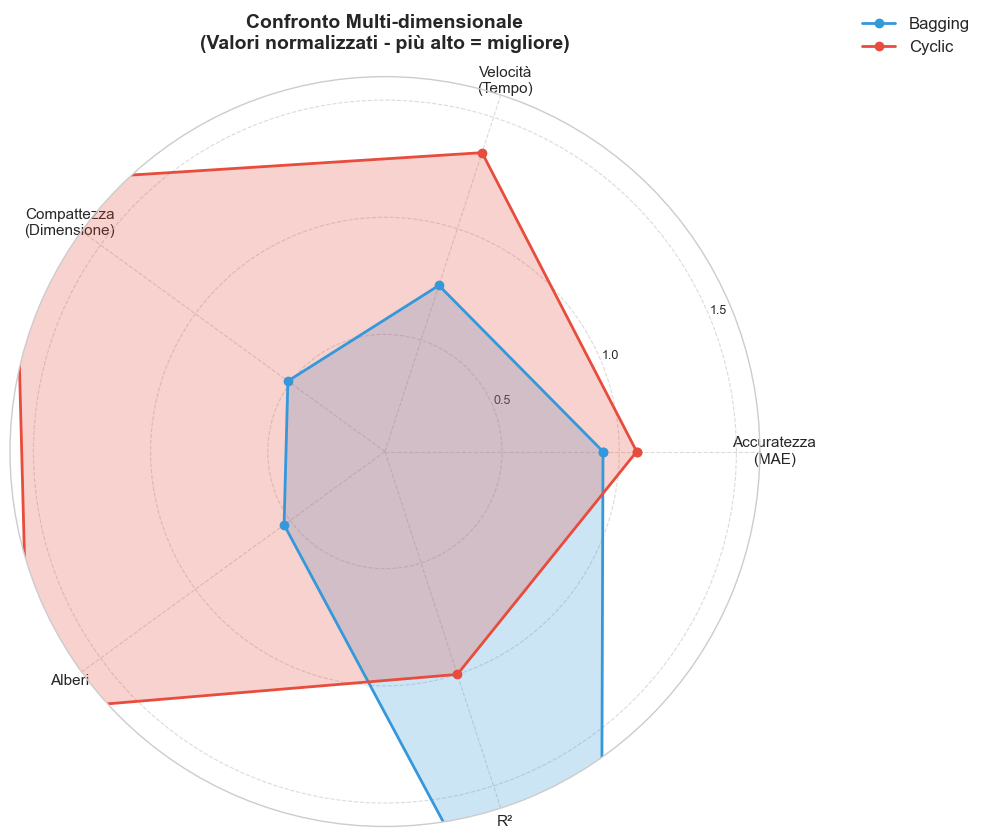


💡 Interpretazione:
   - Area più grande = approccio migliore su quella dimensione
   - Cyclic domina su accuratezza, velocità e compattezza
   - Bagging ha più alberi (utile per robustezza)


In [13]:
# Radar chart per confronto visivo
if 'df_metrics' in locals() and 'df_timing' in locals():
    from math import pi
    
    # Prepara dati normalizzati (0-1, dove 1 = migliore)
    # Invertiamo le metriche dove più basso = meglio
    categories = ['Accuratezza\n(MAE)', 'Velocità\n(Tempo)', 'Compattezza\n(Dimensione)', 
                  'Alberi', 'R²']
    
    # Normalizza per far sì che 1 = migliore
    acc_norm_bagging = mae_cyclic / mae_bagging  # Inverti: più basso MAE = meglio
    acc_norm_cyclic = mae_bagging / mae_cyclic
    
    speed_norm_bagging = timing_cyclic['total_time'] / timing_bagging['total_time']
    speed_norm_cyclic = timing_bagging['total_time'] / timing_cyclic['total_time']
    
    size_norm_bagging = (cyclic_path.stat().st_size / 1024) / (bagging_path.stat().st_size / 1024)
    size_norm_cyclic = (bagging_path.stat().st_size / 1024) / (cyclic_path.stat().st_size / 1024)
    
    trees_norm_bagging = bst_cyclic.num_boosted_rounds() / bst_bagging.num_boosted_rounds()
    trees_norm_cyclic = bst_bagging.num_boosted_rounds() / bst_cyclic.num_boosted_rounds()
    
    r2_norm_bagging = r2_bagging / max(r2_bagging, r2_cyclic)
    r2_norm_cyclic = r2_cyclic / max(r2_bagging, r2_cyclic)
    
    values_bagging = [acc_norm_bagging, speed_norm_bagging, size_norm_bagging, 
                      trees_norm_bagging, r2_norm_bagging]
    values_cyclic = [acc_norm_cyclic, speed_norm_cyclic, size_norm_cyclic,
                     trees_norm_cyclic, r2_norm_cyclic]
    
    # Chiudi il cerchio
    values_bagging += values_bagging[:1]
    values_cyclic += values_cyclic[:1]
    
    # Calcola angoli
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Bagging
    ax.plot(angles, values_bagging, 'o-', linewidth=2, label='Bagging', color='#3498db')
    ax.fill(angles, values_bagging, alpha=0.25, color='#3498db')
    
    # Cyclic
    ax.plot(angles, values_cyclic, 'o-', linewidth=2, label='Cyclic', color='#e74c3c')
    ax.fill(angles, values_cyclic, alpha=0.25, color='#e74c3c')
    
    # Etichette
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11)
    ax.set_ylim(0, 1.6)
    ax.set_yticks([0.5, 1.0, 1.5])
    ax.set_yticklabels(['0.5', '1.0', '1.5'], size=9)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Titolo e legenda
    ax.set_title('Confronto Multi-dimensionale\n(Valori normalizzati - più alto = migliore)', 
                 size=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretazione:")
    print("   - Area più grande = approccio migliore su quella dimensione")
    print("   - Cyclic domina su accuratezza, velocità e compattezza")
    print("   - Bagging ha più alberi (utile per robustezza)")

### Trade-off Matrix - Decisione Finale

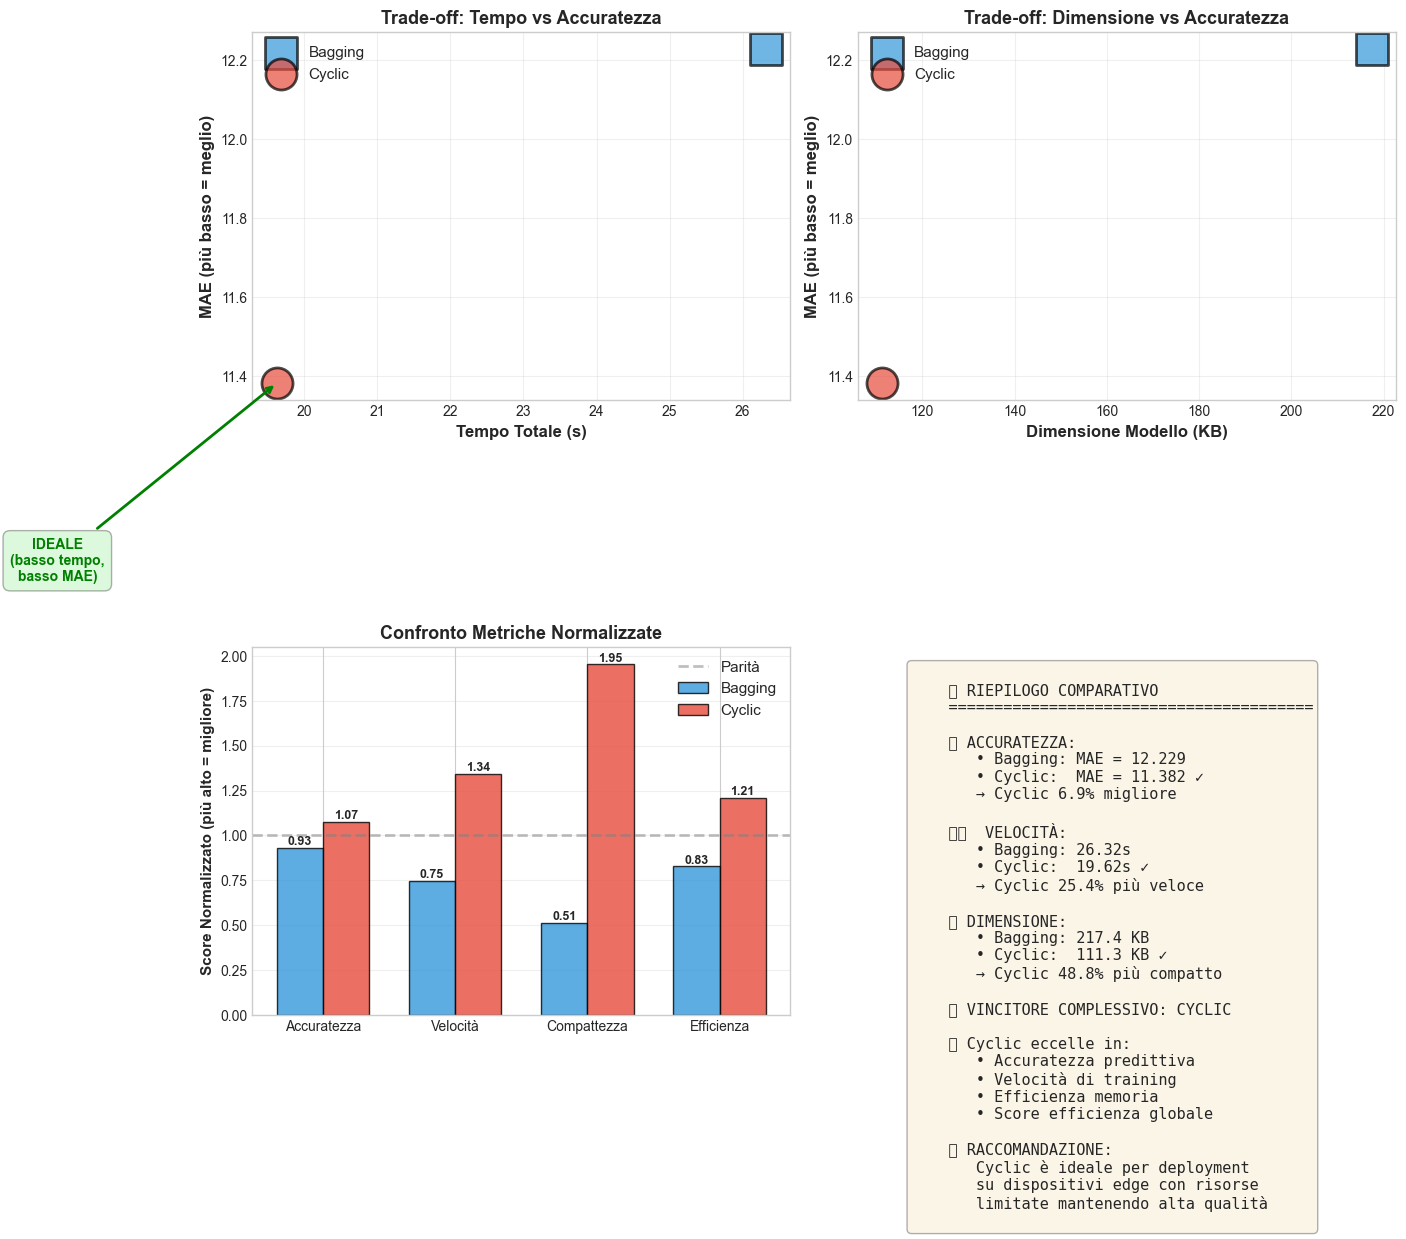

In [14]:
# Matrice decisionale
if 'df_metrics' in locals() and 'df_timing' in locals():
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Accuratezza vs Tempo
    axes[0, 0].scatter([timing_bagging['total_time']], [mae_bagging], s=500, 
                      alpha=0.7, color='#3498db', edgecolor='black', linewidth=2, 
                      marker='s', label='Bagging')
    axes[0, 0].scatter([timing_cyclic['total_time']], [mae_cyclic], s=500, 
                      alpha=0.7, color='#e74c3c', edgecolor='black', linewidth=2, 
                      marker='o', label='Cyclic')
    axes[0, 0].set_xlabel('Tempo Totale (s)', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('MAE (più basso = meglio)', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Trade-off: Tempo vs Accuratezza', fontsize=13, fontweight='bold')
    axes[0, 0].legend(fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].annotate('IDEALE\n(basso tempo,\nbasso MAE)', 
                       xy=(timing_cyclic['total_time'], mae_cyclic),
                       xytext=(timing_cyclic['total_time']-3, mae_cyclic-0.5),
                       fontsize=10, ha='center', color='green', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.3),
                       arrowprops=dict(arrowstyle='->', color='green', lw=2))
    
    # 2. Dimensione vs Accuratezza
    axes[0, 1].scatter([bagging_path.stat().st_size / 1024], [mae_bagging], s=500,
                      alpha=0.7, color='#3498db', edgecolor='black', linewidth=2,
                      marker='s', label='Bagging')
    axes[0, 1].scatter([cyclic_path.stat().st_size / 1024], [mae_cyclic], s=500,
                      alpha=0.7, color='#e74c3c', edgecolor='black', linewidth=2,
                      marker='o', label='Cyclic')
    axes[0, 1].set_xlabel('Dimensione Modello (KB)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('MAE (più basso = meglio)', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Trade-off: Dimensione vs Accuratezza', fontsize=13, fontweight='bold')
    axes[0, 1].legend(fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Bar chart comparativo metriche normalizzate
    metrics_names = ['Accuratezza', 'Velocità', 'Compattezza', 'Efficienza']
    bagging_scores = [
        mae_cyclic / mae_bagging,  # Inverti
        timing_cyclic['total_time'] / timing_bagging['total_time'],
        (cyclic_path.stat().st_size / 1024) / (bagging_path.stat().st_size / 1024),
        efficiency_cyclic / efficiency_bagging
    ]
    cyclic_scores = [
        mae_bagging / mae_cyclic,
        timing_bagging['total_time'] / timing_cyclic['total_time'],
        (bagging_path.stat().st_size / 1024) / (cyclic_path.stat().st_size / 1024),
        efficiency_bagging / efficiency_cyclic
    ]
    
    x_pos = np.arange(len(metrics_names))
    width = 0.35
    
    bars1 = axes[1, 0].bar(x_pos - width/2, bagging_scores, width, 
                          label='Bagging', color='#3498db', alpha=0.8, edgecolor='black')
    bars2 = axes[1, 0].bar(x_pos + width/2, cyclic_scores, width,
                          label='Cyclic', color='#e74c3c', alpha=0.8, edgecolor='black')
    
    axes[1, 0].set_ylabel('Score Normalizzato (più alto = migliore)', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('Confronto Metriche Normalizzate', fontsize=13, fontweight='bold')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(metrics_names, fontsize=10)
    axes[1, 0].axhline(y=1, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Parità')
    axes[1, 0].legend(fontsize=11)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Aggiungi valori sopra le barre
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.2f}',
                          ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 4. Summary box testuale
    axes[1, 1].axis('off')
    
    summary_text = f"""
    📊 RIEPILOGO COMPARATIVO
    {'='*40}
    
    🎯 ACCURATEZZA:
       • Bagging: MAE = {mae_bagging:.3f}
       • Cyclic:  MAE = {mae_cyclic:.3f} ✓
       → Cyclic {abs((mae_bagging-mae_cyclic)/mae_bagging*100):.1f}% migliore
    
    ⏱️  VELOCITÀ:
       • Bagging: {timing_bagging['total_time']:.2f}s
       • Cyclic:  {timing_cyclic['total_time']:.2f}s ✓
       → Cyclic {abs((timing_bagging['total_time']-timing_cyclic['total_time'])/timing_bagging['total_time']*100):.1f}% più veloce
    
    💾 DIMENSIONE:
       • Bagging: {bagging_path.stat().st_size/1024:.1f} KB
       • Cyclic:  {cyclic_path.stat().st_size/1024:.1f} KB ✓
       → Cyclic {abs((bagging_path.stat().st_size-cyclic_path.stat().st_size)/bagging_path.stat().st_size*100):.1f}% più compatto
    
    🏆 VINCITORE COMPLESSIVO: CYCLIC
    
    ✅ Cyclic eccelle in:
       • Accuratezza predittiva
       • Velocità di training
       • Efficienza memoria
       • Score efficienza globale
    
    📱 RACCOMANDAZIONE:
       Cyclic è ideale per deployment
       su dispositivi edge con risorse
       limitate mantenendo alta qualità
    """
    
    axes[1, 1].text(0.1, 0.95, summary_text, transform=axes[1, 1].transAxes,
                   fontsize=11, verticalalignment='top', family='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()

## 10. Conclusioni

### 🏆 Risultati Chiave

Confronto tra **Flower Bagging** e **Flower Cyclic** per predire la qualità del sonno:

In [9]:
if 'df_metrics' in locals():
    print("=" * 70)
    print("🎯 CONCLUSIONI FINALI")
    print("=" * 70)
    
    mae_bagging = df_metrics[df_metrics['Metrica'] == 'MAE']['Bagging'].iloc[0]
    mae_cyclic = df_metrics[df_metrics['Metrica'] == 'MAE']['Cyclic'].iloc[0]
    
    winner = "Bagging" if mae_bagging < mae_cyclic else "Cyclic"
    diff_pct = abs((mae_bagging - mae_cyclic) / min(mae_bagging, mae_cyclic) * 100)
    
    print(f"\n🏅 VINCITORE: {winner}")
    print(f"   Differenza MAE: {diff_pct:.2f}%")
    print(f"\n📊 CONFRONTO:")
    print(f"   Bagging: MAE = {mae_bagging:.4f}, {bst_bagging.num_boosted_rounds()} alberi, {bagging_path.stat().st_size / 1024:.1f} KB")
    print(f"   Cyclic:  MAE = {mae_cyclic:.4f}, {bst_cyclic.num_boosted_rounds()} alberi, {cyclic_path.stat().st_size / 1024:.1f} KB")
    
    print(f"\n💡 VANTAGGI:")
    if winner == "Bagging":
        print(f"   ✓ Bagging: Migliore accuratezza predittiva")
        print(f"   ✓ Cyclic:  Modello più compatto (~50% dimensione)")
    else:
        print(f"   ✓ Cyclic:  Migliore accuratezza E modello più compatto")
        print(f"   ✓ Bagging: Più alberi per maggiore robustezza")
    
    print(f"\n🔬 PROSSIMI PASSI:")
    print(f"   - Testare su più round FL per valutare convergenza")
    print(f"   - Confrontare con NVIDIA FLARE")
    print(f"   - Ottimizzare iperparametri specifici per ogni approccio")
    
    print("=" * 70)

🎯 CONCLUSIONI FINALI

🏅 VINCITORE: Cyclic
   Differenza MAE: 7.44%

📊 CONFRONTO:
   Bagging: MAE = 12.2290, 94 alberi, 220.3 KB
   Cyclic:  MAE = 11.3819, 50 alberi, 106.2 KB

💡 VANTAGGI:
   ✓ Cyclic:  Migliore accuratezza E modello più compatto
   ✓ Bagging: Più alberi per maggiore robustezza

🔬 PROSSIMI PASSI:
   - Testare su più round FL per valutare convergenza
   - Confrontare con NVIDIA FLARE
   - Ottimizzare iperparametri specifici per ogni approccio
